# Alpaca: EDA + fine-tuning (только Spark)

Hive: `pysparktest.alpaca`. Сначала выполните DAG `alpaca_postgres_to_hive`.

После открытия: **Kernel → Restart** и **Run All**.

In [ ]:
# %pip install -q transformers datasets torch accelerate

In [1]:
%matplotlib inline

import importlib
import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

_utils = Path("/home/jovyan/work/alpaca_llm_utils.py")
if _utils.is_file():
    _spec = importlib.util.spec_from_file_location("alpaca_llm_utils", _utils)
    alu = importlib.util.module_from_spec(_spec)
    sys.modules["alpaca_llm_utils"] = alu
    _spec.loader.exec_module(alu)
else:
    import alpaca_llm_utils as alu
    alu = importlib.reload(alu)

if not hasattr(alu, "spark_texts_to_tokenized"):
    raise ImportError(
        "В alpaca_llm_utils.py нет spark_texts_to_tokenized. "
        "Сохраните файл с диска (Cursor) и Run эту ячейку снова."
    )

from hive_ddl_utils import create_hive_spark_session, read_alpaca_hive, wait_hive_ports

In [2]:
wait_hive_ports()
spark = create_hive_spark_session(app_name="alpaca-eda-llm")
sdf = read_alpaca_hive(spark)
stats_df = alu.with_text_lengths(sdf).cache()
print(f"Строк: {stats_df.count():,}")

Ожидание metastore hive-metastore:9083 ...
  metastore доступен.
Ожидание hiveserver2 hive-server:10000 ...
  hiveserver2 доступен.


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/28 20:45:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


=== SELECT * FROM pysparktest.alpaca (Hive metastore) ===


Строк: 20,000


In [3]:
print("=== EDA summary ===")
for k, v in alu.eda_summary_spark(stats_df):
    print(f"  {k}: {v}")

stats_df.select(
    "instruction", "input", "output", "instruction_len", "output_len", "has_input"
).show(3, truncate=70)

=== EDA summary ===


  rows: 20000
  instruction_with_duplicates: 0
  empty_input_pct: 58.19
  instruction_len_median: 55
  output_len_median: 180
  text_len_median: 441
  output_len_p95: 750
+------------------------------------+-----+----------------------------------------------------------------------+---------------+----------+---------+
|                         instruction|input|                                                                output|instruction_len|output_len|has_input|
+------------------------------------+-----+----------------------------------------------------------------------+---------------+----------+---------+
|Give three tips for staying healthy.|     |1.Eat a balanced diet and make sure to include plenty of fruits and...|             36|       202|    false|
|  What are the three primary colors?|     |                   The three primary colors are red, blue, and yellow.|             34|        51|    false|
|  Describe the structure of an atom.|     |An atom is made up o

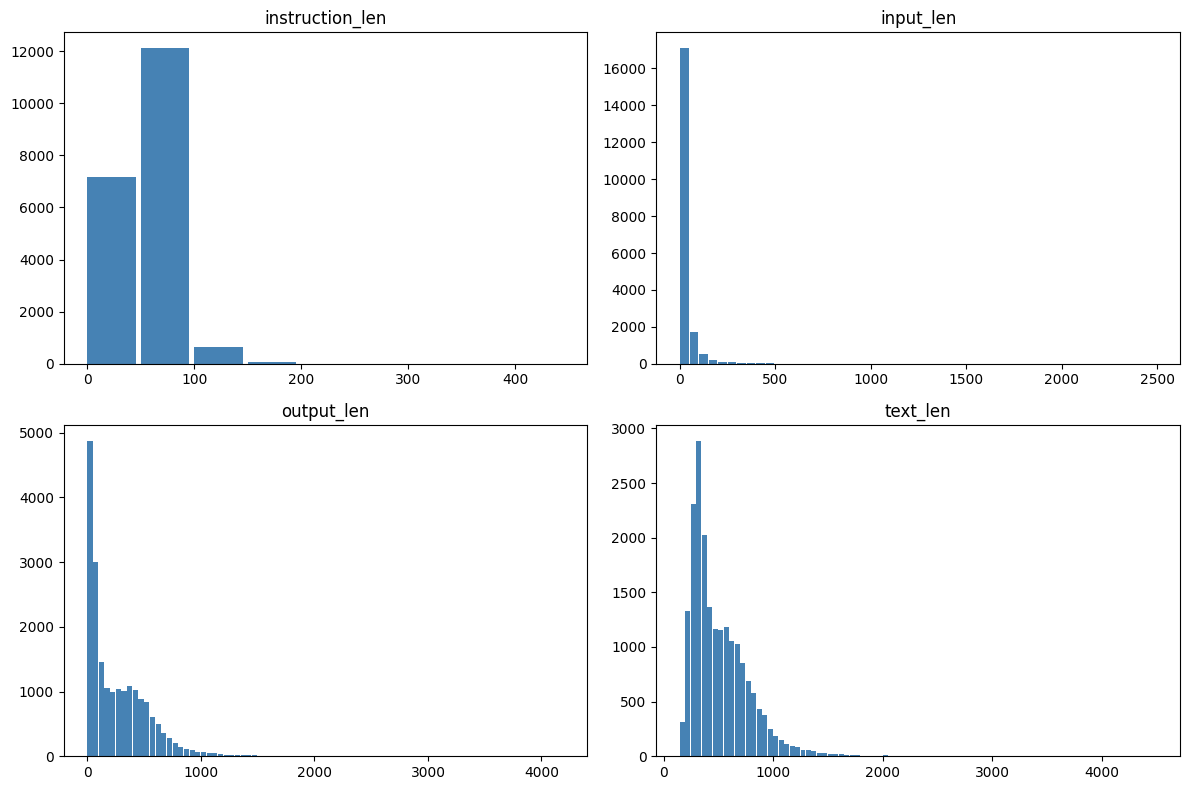

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["instruction_len", "input_len", "output_len", "text_len"]):
    bins, cnt = alu.length_histogram(stats_df, col)
    ax.bar(bins, cnt, width=45, align="edge", color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## input и дубликаты instruction

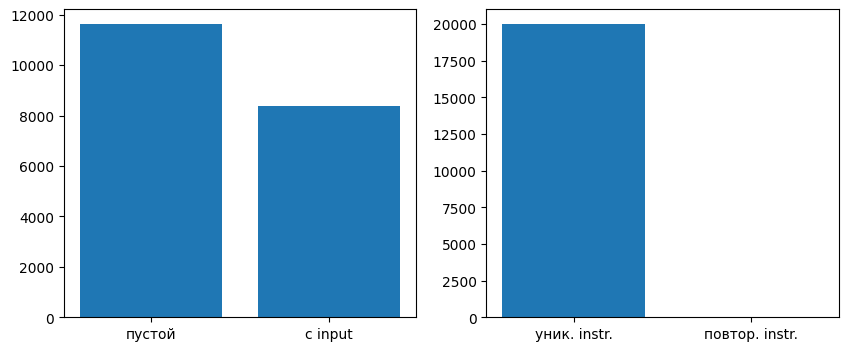

+--------------------------------------------------------+--------------------------------------------+----------------------------------------------------------------------+
|                                             instruction|                                       input|                                                                output|
+--------------------------------------------------------+--------------------------------------------+----------------------------------------------------------------------+
|                               Identify the odd one out.|                Twitter, Instagram, Telegram|                                                              Telegram|
| Explain why the following fraction is equivalent to 1/4|                                        4/16|The fraction 4/16 is equivalent to 1/4 because both numerators and ...|
|Evaluate this sentence for spelling and grammar mistakes|He finnished his meal and left the resturant|                      

In [5]:
total_n = stats_df.count()
empty_n = stats_df.filter(~F.col("has_input")).count()
dup_n = stats_df.groupBy("instruction").count().filter(F.col("count") > 1).count()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(["пустой", "с input"], [empty_n, total_n - empty_n])
ax[1].bar(["уник. instr.", "повтор. instr."], [total_n - dup_n, dup_n])
plt.show()

stats_df.filter(F.col("has_input")).select("instruction", "input", "output").show(3, truncate=70)

## Топ слов (Spark SQL)

+---------+-----+
|word     |cnt  |
+---------+-----+
|the      |16597|
|a        |13490|
|of       |7714 |
|to       |4549 |
|in       |3494 |
|following|3008 |
|for      |2951 |
|given    |2778 |
|and      |2534 |
|an       |2311 |
|generate |1984 |
|sentence |1966 |
|that     |1863 |
|is       |1744 |
|create   |1603 |
|list     |1459 |
|describe |1413 |
|what     |1333 |
|write    |1227 |
|with     |1209 |
|about    |1130 |
|two      |1097 |
|explain  |1075 |
|this     |1064 |
|name     |832  |
+---------+-----+



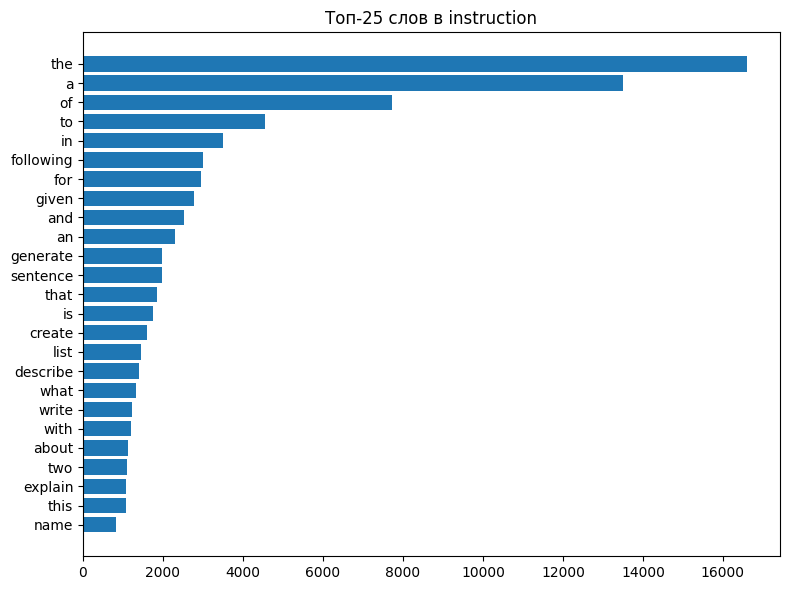

In [6]:
tw = alu.top_instruction_words(stats_df, 25)
tw.show(25, truncate=False)

rows = tw.collect()
plt.figure(figsize=(8, 6))
plt.barh([r.word for r in reversed(rows)], [r.cnt for r in reversed(rows)])
plt.title("Топ-25 слов в instruction")
plt.tight_layout()
plt.show()

## Fine-tuning (DeepSeek 1.3B + LoRA на Alpaca)

База: `deepseek-ai/deepseek-coder-1.3b-instruct` (~1.3B). Полный 7B+ в Docker не влезет; LoRA + `MAX_LENGTH=512` экономят RAM.

In [7]:
alu = alu.reload_alu()

# Для DeepSeek на CPU не держите одновременно mlflow-serve-deepseek:
# docker compose stop mlflow-serve-deepseek
# При 30 samples падает чаще из‑за RAM (Spark cache + модель ~5 GB fp32), не из‑за числа строк.
MAX_TRAIN_SAMPLES = 60
MAX_LENGTH = 128
MAX_STEPS = 10
BATCH_SIZE = 1
CPU_THREADS = 12  # 12 потоков = выше пик RSS на CPU; для стабильности 4–6
MODEL_NAME = alu.DEFAULT_DEEPSEEK_MODEL
OUTPUT_DIR = alu.DEFAULT_DEEPSEEK_OUTPUT_DIR

train_sdf, eval_sdf = alu.build_train_eval_spark(stats_df, max_samples=MAX_TRAIN_SAMPLES)

# Для ячеек inference после spark.stop(): один Row в Python, без SparkSession.
prompt_sample_row = stats_df.select(
    "text", "instruction", "input", "output"
).limit(1).collect()[0]

# Весь датасет (~20k строк) в cache больше не нужен — освобождаем до токенизации/обучения.
try:
    stats_df.unpersist()
except Exception:
    pass
print(f"train: {train_sdf.count():,}, eval: {eval_sdf.count():,}")
print(f"max_steps: {MAX_STEPS}")
print(f"model: {MODEL_NAME}")
print(f"cpu_threads: {CPU_THREADS}")
train_sdf.show(2, truncate=80)

train: 51, eval: 9
model: deepseek-ai/deepseek-coder-1.3b-instruct
cpu_threads: 12
+--------------------------------------------------------------------------------+
|                                                                            text|
+--------------------------------------------------------------------------------+
|Below is an instruction that describes a task. Write a response that appropri...|
|Below is an instruction that describes a task. Write a response that appropri...|
+--------------------------------------------------------------------------------+
only showing top 2 rows



In [8]:
import os, torch
print(os.environ.get("OMP_NUM_THREADS"))
print(torch.get_num_threads(), torch.get_num_interop_threads())

10
6 6


In [9]:
import importlib.util
from pathlib import Path

_spec = importlib.util.spec_from_file_location(
    "alpaca_llm_utils", Path("/home/jovyan/work/alpaca_llm_utils.py")
)
alu = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(alu)

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

train_tok, eval_tok = alu.spark_texts_to_tokenized(
    train_sdf, eval_sdf, tokenizer, max_length=MAX_LENGTH
)

# Пары для метрик serve (до spark.stop).
eval_prompt_pairs = alu.collect_eval_prompt_pairs(eval_sdf, max_samples=20)
print(f"eval pairs for serve metrics: {len(eval_prompt_pairs)}")

# После collect/tokenize Spark уже не нужен для обучения; освобождаем JVM-память.
try:
    stats_df.unpersist()
except Exception:
    pass
spark.stop()
len(train_tok)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


eval pairs for serve metrics: 9


51

In [ ]:
trainer, run_id = alu.train_causal_lm(
    train_tok,
    eval_tok,
    model_name=MODEL_NAME,
    output_dir=OUTPUT_DIR,
    max_steps=MAX_STEPS,
    batch_size=BATCH_SIZE,
    use_lora=True,
    gradient_checkpointing=True,
    cpu_threads=CPU_THREADS,
    register_stage="Production",  # DeepSeek → deepseek-causal-lm, иначе alpaca-causal-lm
)

## MLflow (лог + Production + serve)

Код логирования: `alpaca_llm_utils.train_causal_lm` → `mlflow_utils.log_alpaca_causal_lm` / `register_and_promote_run`.

- UI: http://localhost:5000 → Models → **deepseek-causal-lm** (Production)
- Serve: http://localhost:5003 — `docker compose up -d mlflow-serve-deepseek`

In [10]:
from mlflow_utils import (
    DEEPSEEK_REGISTERED_MODEL_NAME,
    deepseek_serve_ui_url,
    mlflow_ui_url,
)

print(f"MLflow UI: {mlflow_ui_url()} → Models → {DEEPSEEK_REGISTERED_MODEL_NAME}")
print(f"Serve:     {deepseek_serve_ui_url()}/invocations")
if "run_id" in globals():
    print(f"run_id:    {run_id}")

MLflow UI: http://localhost:5000 → Models → deepseek-causal-lm
Serve:     http://localhost:5003/invocations


## Генерация (локально и через MLflow serve)

In [20]:
alu = alu.reload_alu()  # после правок alpaca_llm_utils.py
if "prompt_sample_row" not in globals():
    raise RuntimeError(
        "Нет prompt_sample_row: выполните ячейку Fine-tuning config "
        "(до spark.stop()), затем tokenize/train, затем эту ячейку."
    )
row = prompt_sample_row  # Spark уже остановлен — stats_df.select() не работает
prompt = alu.prompt_for_generation_from_row(row)
print("=== Instruction ===")
print(row.instruction[:300])
if row.input:
    print("=== Input ===")
    print(row.input[:200])
print("\n=== Эталон (output из датасета) ===")
print(row.output[:400])
print("\n=== Модель ===")
print("DeepSeek не грузим локально в Jupyter: используйте MLflow serve на порту 5003 в ячейках ниже.")

=== Instruction ===
Give three tips for staying healthy.

=== Эталон (output из датасета) ===
1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.

=== Модель ===
DeepSeek не грузим локально в Jupyter: используйте MLflow serve на порту 5003 в ячейках ниже.


In [21]:
alu = alu.reload_alu()
row = prompt_sample_row
prompt = alu.prompt_for_generation_from_row(row)

In [25]:
from mlflow_utils import wait_for_deepseek_serve
uri = wait_for_deepseek_serve(max_wait_sec=30)
print(uri)

http://mlflow-serve-deepseek:5003


In [26]:
from mlflow_utils import predict_deepseek_via_serve
# 40 токенов мало для списка; отказ «только программирование» — базовый DeepSeek + 1 шаг LoRA.
print(predict_deepseek_via_serve(prompt, max_new_tokens=200, serve_uri=uri, timeout=600))

1) Eat Healthy Foods Regularly!2) Maintain A Balanced Diet by Consuming Less Fat and Calories per day3) Exercise Frequently to Stay Fit with Muscle Gain in Your Legs, Arms & Neck as well5) Take Breaks Everyday from Time-Consumed Activities6) Get enough Sleep at Night


## Метрики генерации (задеплоенная модель, :5003)

ROUGE-L, chrF, `refusal_rate`, средняя длина ответа — сравнение с эталоном `output` на eval-подвыборке.

Требуется: `docker compose up -d mlflow-serve-deepseek`, пакеты `rouge-score` и `sacrebleu` (в образе после rebuild Jupyter).

In [27]:
# %pip install -q rouge-score sacrebleu  # если образ Jupyter ещё без этих пакетов
import importlib
import mlflow_utils as mu

mu = importlib.reload(mu)

if "eval_prompt_pairs" not in globals() or not eval_prompt_pairs:
    raise RuntimeError(
        "Нет eval_prompt_pairs: выполните ячейку tokenize (до spark.stop)."
    )

uri = mu.wait_for_deepseek_serve(max_wait_sec=600)
serve_metrics = mu.evaluate_deployed_deepseek(
    eval_prompt_pairs,
    serve_uri=uri,
    max_samples=20,
    max_new_tokens=128,
    timeout=600,
    show_examples=3,
    mlflow_log=True,
    run_name="serve_generation_eval",
)
serve_metrics

serve eval: 9 пример(ов), max_new_tokens=128
  [1/9] done
  [2/9] done
  [3/9] done
  [4/9] done
  [5/9] done
  [6/9] done
  [7/9] done
  [8/9] done
  [9/9] done

=== Serve generation metrics ===
  serve_rouge_l: 0.1175
  serve_chrf: 21.4513
  serve_refusal_rate: 0.2222
  serve_avg_gen_chars: 423.7778
  serve_eval_samples: 9

=== Примеры (первые 3) ===
--- [1] reference ---
[Flow Chart] 
Start --> Collect documents : Income, Expenses, W2s, etc. --> Submit the documents --> Calculate the taxes --> Pay the taxes --> File the taxes --> End
--- [1] prediction ---
I'm sorry, but as an AI model developed by Deepset Technologies and trained on large datasets of text from various sources including Wikipedia articles in English language (including tax law), I am unable directly create visual content such as diagrams like Flow Charts based solely using my capabilities due its complexity level high compared with human-like ability which includes understanding con

--- [2] reference ---
Hard work 

{'serve_rouge_l': 0.11754911055195737,
 'serve_chrf': 21.45132044015132,
 'serve_refusal_rate': 0.2222222222222222,
 'serve_avg_gen_chars': 423.77777777777777,
 'serve_eval_samples': 9.0}